# Real Time vehicle Detection  &  Real-Time Person Detection 

**Stack:** YOLOv8 (Ultralytics) for person detection  · OpenCV for video I/O

Built in thwo stages:
1. Run YOLOv8 on a single static image as a sanity check
2. Detect people in a live webcam feed and draw bounding boxes around them




## 1. Object Detection on a Static Image

Load a test image and confirm it's readable before touching the model.

(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

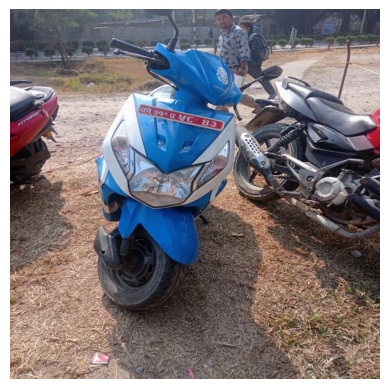

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("C:\\Users\\ASUS\\OneDrive\\Desktop\\AI & ML\\projects\\val\\val\\Bikevalid64.jpg")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")

In [2]:
print(image.shape)

(640, 640, 3)


Load YOLOv8 and run it on the same image.

In [3]:
from ultralytics import YOLO

In [4]:
model = YOLO("yolov8n.pt")

In [5]:
results = model("C:\\Users\\ASUS\\OneDrive\\Desktop\\AI & ML\\projects\\val\\val\\Bikevalid64.jpg")


image 1/1 C:\Users\ASUS\OneDrive\Desktop\AI & ML\projects\val\val\Bikevalid64.jpg: 640x640 3 persons, 3 motorcycles, 1 boat, 1 backpack, 210.5ms
Speed: 4.2ms preprocess, 210.5ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


In [6]:
results[0].show()

In [7]:
results[0].save(filename="output.jpg")

'output.jpg'

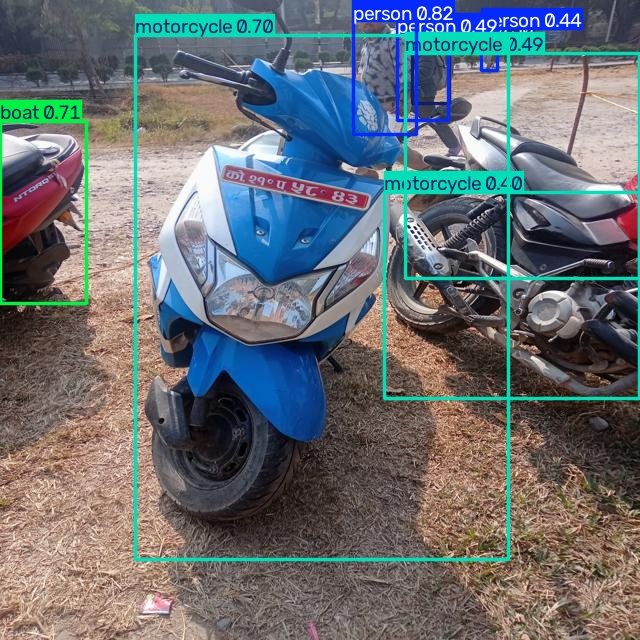

In [8]:
from PIL import Image 
Image.open("output.jpg")

## 2. Real-Time Person Detection (Webcam)

First real-time version: run YOLOv8 on every webcam frame and draw a box around anything classified as `person`.

**Requires a local webcam — run this in a local Jupyter install, not a hosted/cloud notebook.**

In [9]:
from ultralytics import YOLO
import cv2

model = YOLO('yolov8n.pt')  # Load the YOLOv8n model

# Open webcam (0 = default camera)
cap = cv2.VideoCapture(0)

while True:
    # Read one frame from the webcam
    success, frame = cap.read()
    if not success:
        break

    # Run YOLO on this frame
    results = model(frame, stream=True)

    for result in results:
        for box in result.boxes:
            label = result.names[int(box.cls)]
            if label == 'person':
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, label, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Show the live frame
    cv2.imshow('Live Face Detection', frame)

    # Press 'q' to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


0: 480x640 1 person, 226.3ms
Speed: 2.9ms preprocess, 226.3ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 142.5ms
Speed: 3.0ms preprocess, 142.5ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 137.6ms
Speed: 2.7ms preprocess, 137.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 88.2ms
Speed: 1.9ms preprocess, 88.2ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 87.0ms
Speed: 2.3ms preprocess, 87.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 71.6ms
Speed: 2.2ms preprocess, 71.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 79.1ms
Speed: 2.0ms preprocess, 79.1ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.8ms
Speed: 1.7ms preprocess, 70.8ms inference, 1.3ms postprocess per image at shape (1,

## Key Learnings

- Sanity-checking a model on one static image before wiring it into a real-time loop catches setup issues early and cheaply
- OpenCV reads in BGR, not RGB — needs `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` before display in `matplotlib`
- Real-time inference has a cost budget: YOLOv8n is light enough to run per-frame, but secondary analysis models need frame-skipping to stay usable

## Requirements

```
ultralytics
opencv-python
matplotlib

